In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import networkx as nx
import pandas as pd
import scipy.sparse as sp
import random
import networkx as nx
from  networkx.algorithms.approximation import min_weighted_dominating_set as dominating_set
import seaborn as sns


In [2]:
# --- CLASSES DE STRATÉGIE DE VACCINATION ---
class VaccinationStrategy:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def _fill_remaining_vaccinations(self, vaccinated, ids, nI):
        
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
            remaining = list(set(range(self.n)) - set(ids))
            random.shuffle(remaining)
            for idx in remaining[:nI - len(ids)]:
                vaccinated[idx] = True
        return vaccinated

class NoVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        return [False] * self.n

class DegreeVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        degrees = [self.G.degree(node) for node in ids]
        ids = [x for _, x in sorted(zip(degrees, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class DegreeCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.degree_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class BetweennessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.betweenness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class ClosenessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.closeness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class EigenVectorCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.eigenvector_centrality(self.G, max_iter=1000)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class RandomVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_, percent):
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        if dominating_set_ is None:
            ids = list(range(self.n))
        else:
            ids = list(dominating_set_)
        random.shuffle(ids)
        for idx in ids[:nI]:
            vaccinated[idx] = True
        return vaccinated

class VaccinationStrategyFactory:
    def __init__(self, G):
        self.G = G
    def get_strategy(self, strategy_name):
        if strategy_name == "no_vac":
            return NoVaccinationStrategy(self.G)
        elif strategy_name == "degree":
            return DegreeVaccinationStrategy(self.G)
        elif strategy_name == "degree_centrality":
            return DegreeCentralityVaccinationStrategy(self.G) # Corrigé (NameError original)
        elif strategy_name == "betweenness_centrality":
            return BetweennessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "closeness_centrality":
            return ClosenessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "eigenvector_centrality":
            return EigenVectorCentralityVaccinationStrategy(self.G)
        elif strategy_name == "random":
            return RandomVaccinationStrategy(self.G)
        else:
            raise ValueError("Invalid vaccination strategy")

# --- PIPELINE GLOBAL D'ÉVALUATION ---


In [23]:
def plot_comparison_bar_charts(df_ds, df_nds, metrics=None, figsize=(6.5, 6.5), palette='viridis', output_path = "structural_comparison_bar_chart.eps"):
    if metrics is None:
        metrics = [
            'I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',
            'Algebraic_Connectivity', 'Total_Reinfections',
            'Mean_Effective_Degree', 'Vaccine_Efficiency', 'Persistence'
        ]

    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Prepare data for plotting
        plot_data = pd.DataFrame({
            'Strategy': df_ds.index.tolist() + df_nds.index.tolist(),
            'Value': df_ds[metric].tolist() + df_nds[metric].tolist(),
            'Scenario': ['DS'] * len(df_ds) + ['No DS'] * len(df_nds)
        })

        # Plot side-by-side bar plots using seaborn
        sns.barplot(data=plot_data, x='Strategy', y='Value', hue='Scenario', ax=ax, palette=palette)
        ax.set_title(f'Comparison of {metric}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

In [14]:
G=nx.read_weighted_edgelist('NetSci.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

## Structural Network Analysis for Vaccination Strategies

This section delves into the structural properties of the network following the application of various vaccination strategies, both with and without the pre-selection of vaccination candidates using a dominating set (DS). Understanding these structural changes is paramount for evaluating the efficacy of intervention strategies in the context of epidemic dynamics.

Key structural metrics, such as clustering coefficients, spectral radius, and characteristics of connected components (number, average size, and largest component diameter), provide critical insights into how network connectivity and pathogen propagation potential are altered. These metrics are crucial indicators of network fragmentation and resilience against the spread of infectious diseases. The goal is to identify strategies that effectively reduce network connectivity and promote fragmentation, thereby mitigating epidemic risk.

In [33]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.approximation import min_weighted_dominating_set as dominating_set
import scipy.sparse as sp

# Redefine/Correct clustering_coefficient and spectral_radius for robustness and clarity
def clustering_coefficient(G):
    """
    Calculates the average local clustering coefficient and global clustering coefficient (transitivity)
    for a given NetworkX graph.
    Handles small graphs and graphs with no edges gracefully.
    """
    if G.number_of_nodes() <= 1:
        return 0.0, 0.0 # Clustering is undefined or 0 for 0 or 1 node
    if G.number_of_edges() == 0:
        return 0.0, 0.0 # No edges means no triangles, hence 0 clustering

    avg_local_clustering = nx.average_clustering(G)
    global_transitivity = nx.transitivity(G)

    return avg_local_clustering, global_transitivity

def size_vs_walk(G):
  """
  Calculates the sizes and diameters (walks) for all connected components of a graph.
  """
  components = list(nx.connected_components(G))
  sizes = []
  walks = []
  for c in components:
    subgraph = G.subgraph(c)
    if subgraph.number_of_nodes() > 1: # Diameter is defined for components with >1 node
        sizes.append(len(c))
        try:
            walks.append(nx.diameter(subgraph))
        except nx.NetworkXError:
            # Handle cases where diameter might not be calculable (e.g., disconnected nodes within the component, though nx.connected_components should prevent this)
            walks.append(0) # Or np.nan depending on desired handling
    elif subgraph.number_of_nodes() == 1:
        sizes.append(1)
        walks.append(0) # A single node component has diameter 0
  return sizes, walks

def spectral_radius(G):
    """
    Calculates the spectral radius of the adjacency matrix of a given NetworkX graph.
    Handles empty graphs and graphs with no edges gracefully.
    """
    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        return 0.0

    A = nx.adjacency_matrix(G)
    A_dense = A.toarray() if sp.issparse(A) else A # Convert sparse to dense if necessary

    # np.linalg.eigvalsh is for symmetric real matrices, which adjacency matrices are.
    # It's generally faster and more stable than eigvals for this specific case.
    eigenvalues = np.linalg.eigvalsh(A_dense)

    # The spectral radius is the largest absolute eigenvalue.
    return np.max(np.abs(eigenvalues))

# Helper function for calculating the diameter of the largest connected component
def calculate_largest_component_diameter(G):
    """
    Calculates the diameter of the largest connected component of the graph.
    This represents the maximum shortest path length within that largest component.

    Args:
        G (nx.Graph): The NetworkX graph.

    Returns:
        int or float: The diameter of the largest connected component.
                      Returns 0 if the graph is empty or has no components with more than one node.
    """
    if G.number_of_nodes() == 0:
        return 0

    # Get all connected components
    components = list(nx.connected_components(G))

    if not components:
        return 0 # No components found (e.g., empty graph)

    # Find the largest component
    largest_component = max(components, key=len)

    # If the largest component has 0 or 1 node, diameter is 0
    if len(largest_component) <= 1:
        return 0

    # Create a subgraph from the largest component
    subgraph_largest_component = G.subgraph(largest_component)

    # Calculate the diameter of this subgraph. It's guaranteed to be connected.
    try:
        diameter = nx.diameter(subgraph_largest_component)
        return diameter
    except nx.NetworkXError:
        # This exception should ideally not be hit if len(largest_component) > 1
        # and it's from nx.connected_components.
        return 0 # Fallback in case of unexpected graph structure

# Redefine evaluate_strategy_properties to ensure it uses the corrected functions
# and returns structured metrics.
# This function is conceptually similar to the original evaluate_strategy
# but with improved return structure and robust handling of graph properties.
def evaluate_strategy_properties(strategy_name, vc, use_ds, G):
    """
    Evaluates graph properties (clustering and spectral radius) after vaccination
    for a given strategy.

    Args:
        strategy_name (str): Name of the vaccination strategy.
        vc (float): Vaccination coverage percentage (e.g., 0.35).
        use_ds (bool): Whether to use dominating set to select candidates for vaccination.
        G (nx.Graph): The original NetworkX graph.

    Returns:
        dict: A dictionary containing calculated metrics.
    """
    # Assuming VaccinationStrategyFactory and related classes are defined in previous cells
    # and are accessible in the global scope.
    strategy_factory = VaccinationStrategyFactory(G)
    strategy = strategy_factory.get_strategy(strategy_name)

    population_to_consider_for_vaccination = set()
    if use_ds:
        try:
            # min_weighted_dominating_set returns an approximation of a minimum dominating set
            # For unweighted graphs, it treats all weights as 1.
            population_to_consider_for_vaccination = dominating_set(G)
        except nx.NetworkXPointlessConcept: # Graph is empty
            population_to_consider_for_vaccination = set()
        except Exception as e:
            # Fallback if dominating_set calculation fails (e.g., very large graph, complex structure)
            print(f"Warning: dominating_set for {strategy_name} (ds={use_ds}) failed: {e}. Falling back to all nodes for candidate pool.")
            population_to_consider_for_vaccination = set(G.nodes())
    else:
        population_to_consider_for_vaccination = set(G.nodes())

    # Select vaccinated nodes based on the strategy.
    # 'select_vaccinated' returns a boolean list where True means vaccinated.
    # The original G.nodes() order is implicitly used for this mapping.
    all_nodes_list = list(G.nodes())
    removed_nodes_mask = strategy.select_vaccinated(population_to_consider_for_vaccination, vc)

    # Map the boolean mask back to actual node IDs that were removed
    vaccinated_nodes = {all_nodes_list[i] for i, is_vaccinated in enumerate(removed_nodes_mask) if is_vaccinated}

    # The remaining nodes form the induced graph for property calculation.
    remaining_nodes = set(G.nodes()) - vaccinated_nodes

    # Handle edge case where no nodes or all nodes are removed
    if not remaining_nodes:
        return {
            'Strategy': strategy_name,
            'Avg_Local_Clustering': 0.0,
            'Global_Clustering': 0.0,
            'Spectral_Radius': 0.0,
            'Num_Nodes_Remaining': 0,
            'Num_Vaccinated': len(vaccinated_nodes),
            'Num_Components': 0,
            'Avg_Component_Size': 0.0,
            'Largest_Component_Diameter': 0.0
        }, {'Component_sizes_vs_Walks': (None, None)}

    induced_graph = G.subgraph(remaining_nodes)

    avg_local_clustering, global_transitivity = clustering_coefficient(induced_graph)
    spectral_rad = spectral_radius(induced_graph)

    num_components = 0
    avg_component_size = 0.0
    largest_component_diameter_val = 0.0
    component_sizes_vs_walks = ([], []) # Initialize as empty lists

    if induced_graph.number_of_nodes() > 0:
        components = list(nx.connected_components(induced_graph))
        num_components = len(components)
        if num_components > 0:
            component_sizes = [induced_graph.subgraph(c).number_of_nodes() for c in components]
            avg_component_size = np.mean(component_sizes)
            largest_component_diameter_val = calculate_largest_component_diameter(induced_graph)
            component_sizes_vs_walks = size_vs_walk(induced_graph)

    return {
        'Strategy': strategy_name,
        'Avg_Local_Clustering': avg_local_clustering,
        'Global_Clustering': global_transitivity,
        'Spectral_Radius': spectral_rad,
        'Num_Nodes_Remaining': induced_graph.number_of_nodes(),
        'Num_Vaccinated': len(vaccinated_nodes),
        'Num_Components': num_components,
        'Avg_Component_Size': avg_component_size,
        'Largest_Component_Diameter': largest_component_diameter_val
    }, {'Component_sizes_vs_Walks': component_sizes_vs_walks}

def run_graph_property_comparison(G, vc, strategies_list):
    """
    Runs the evaluation of graph properties for multiple vaccination strategies
    with and without using a dominating set, collecting results into DataFrames
    and separate data for component size vs. walks plots.

    Args:
        G (nx.Graph): The NetworkX graph.
        vc (float): Vaccination coverage percentage.
        strategies_list (list): List of strategy names.

    Returns:
        tuple: (df_ds, df_nds, sizes_walks_data_ds, sizes_walks_data_nds)
               - df_ds: pandas DataFrame for dominating set scenarios.
               - df_nds: pandas DataFrame for no dominating set scenarios.
               - sizes_walks_data_ds: dict {strategy_name: (sizes_list, walks_list)} for DS.
               - sizes_walks_data_nds: dict {strategy_name: (sizes_list, walks_list)} for No DS.
    """
    results_ds = []
    results_nds = []
    sizes_walks_data_ds = {} # To store {strategy_name: (sizes, walks)}
    sizes_walks_data_nds = {} # To store {strategy_name: (sizes, walks)}

    for strategy_name in strategies_list:
        print(f"Evaluating strategy: {strategy_name}")

        # Scenario 1: With Dominating Set (use_ds=True)
        metrics_ds, current_sizes_walks_ds = evaluate_strategy_properties(strategy_name, vc, True, G)
        results_ds.append(metrics_ds)
        sizes_walks_data_ds[strategy_name] = current_sizes_walks_ds['Component_sizes_vs_Walks']

        # Scenario 2: Without Dominating Set (use_ds=False)
        metrics_nds, current_sizes_walks_nds = evaluate_strategy_properties(strategy_name, vc, False, G)
        results_nds.append(metrics_nds)
        sizes_walks_data_nds[strategy_name] = current_sizes_walks_nds['Component_sizes_vs_Walks']

    df_ds = pd.DataFrame(results_ds).set_index('Strategy')
    df_nds = pd.DataFrame(results_nds).set_index('Strategy')

    return df_ds, df_nds, sizes_walks_data_ds, sizes_walks_data_nds

# --- Execution ---
# G is already loaded from previous cells, e.g., G = nx.read_weighted_edgelist('Net data 2026/Dublin.txt')
# n = len(G) is also defined.

# Re-define G from previous cell to ensure it's available
G=nx.read_weighted_edgelist('NetSci.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

# Define vaccination coverage and list of strategies
vc_percentage = 0.35 # Example vaccination coverage
strategies = ["no_vac", "random", "degree_centrality",
              "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

print(f"\n--- Evaluating Graph Properties for {vc_percentage*100}% Vaccination Coverage ---")
df_properties_ds, df_properties_nds, sizes_walks_ds, sizes_walks_nds = run_graph_property_comparison(G, vc_percentage, strategies)

print("\nResults with Dominating Set for candidate selection:")
print(df_properties_ds)

print("\nResults without Dominating Set for candidate selection:")
print(df_properties_nds)

# --- Plotting ---
# Metrics to plot based on the output of evaluate_strategy_properties (for bar charts)
plot_metrics = [
    #'Avg_Local_Clustering',
    #'Global_Clustering',
    'Spectral_Radius',
    'Num_Components',
    'Avg_Component_Size',
    'Largest_Component_Diameter'
]

print("\n--- Generating Comparison Bar Charts for Graph Properties ---")
# The plot_comparison_bar_charts function is defined in a previous cell (dgpjoO9wl8K6)
# It will be called by cell aO_ITMJdl0uE

print("\n--- Generating Component Size vs. Diameter (Walks) Plots (Part 1) ---")
# Split strategies for two plots
strategies_part1 = strategies[:len(strategies)//2]
strategies_part2 = strategies[len(strategies)//2:]


--- Evaluating Graph Properties for 35.0% Vaccination Coverage ---
Evaluating strategy: no_vac
Evaluating strategy: random
Evaluating strategy: degree_centrality
Evaluating strategy: betweenness_centrality
Evaluating strategy: closeness_centrality
Evaluating strategy: eigenvector_centrality

Results with Dominating Set for candidate selection:
                        Avg_Local_Clustering  Global_Clustering  \
Strategy                                                          
no_vac                              0.741231           0.430575   
random                              0.180723           0.937500   
degree_centrality                   0.182186           0.937500   
betweenness_centrality              0.170040           0.933333   
closeness_centrality                0.170040           0.933333   
eigenvector_centrality              0.182186           0.937500   

                        Spectral_Radius  Num_Nodes_Remaining  Num_Vaccinated  \
Strategy                            

In [29]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
import multiprocessing
import numpy as np
from saw_workers import worker_batch, build_index_structures  # <-- import top-level worker

def count_walks_parallel(induced_graph, max_k, n_workers=None):
    if n_workers is None:
        n_workers = multiprocessing.cpu_count()

    adj_dict = {
        node: list(induced_graph.neighbors(node))
        for node in induced_graph.nodes()
    }

    nodes, node_to_idx, adj_list_indexed, n_nodes = build_index_structures(adj_dict)

    if not nodes:
        return [0] * max_k

    node_indices = list(range(n_nodes))
    chunks = np.array_split(node_indices, min(n_workers, len(node_indices)))

    total_counts = [0] * (max_k + 1)

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [
            executor.submit(worker_batch, chunk.tolist(), adj_list_indexed, max_k, n_nodes)
            for chunk in chunks if len(chunk) > 0
        ]
        for fut in as_completed(futures):
            res = fut.result()
            for k in range(1, max_k + 1):
                total_counts[k] += res[k]

    return total_counts[1:]

In [30]:
def plot_self_avoiding_walks_split(G, vc, strategies_list, max_k=10, base_output_path="simple_walk_distribution"):
    """
    Plots the number of self-avoiding walks N(k) vs length k using parallel processing.
    """
    mid_point = len(strategies_list) // 2 if len(strategies_list) % 2 == 0 else (len(strategies_list) // 2) + 1
    parts = [strategies_list[:mid_point], strategies_list[mid_point:]]
    
    k_values = np.arange(1, max_k + 1)
    strategy_factory = VaccinationStrategyFactory(G)
    all_nodes_list = list(G.nodes())
    
    for part_idx, sub_strategies in enumerate(parts, start=1):
        num_strategies = len(sub_strategies)
        num_cols = 2
        num_rows = int(np.ceil(num_strategies / num_cols))
        
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 4 * num_rows), squeeze=False)
        fig.suptitle(f'Self-Avoiding Walks (No Circuits): DS vs No DS (Part {part_idx})', fontsize=16, y=0.99)
        
        for idx, strategy_name in enumerate(sub_strategies):
            row = idx // num_cols
            col = idx % num_cols
            ax = axes[row, col]
            
            for use_ds, label, color, marker in [(True, 'With DS', '#1f77b4', 'o'), (False, 'No DS', '#ff7f0e', 's')]:
                strategy = strategy_factory.get_strategy(strategy_name)
                
                if use_ds:
                    try: population_to_consider = dominating_set(G)
                    except: population_to_consider = set(G.nodes())
                else:
                    population_to_consider = set(G.nodes())
                    
                removed_mask = strategy.select_vaccinated(population_to_consider, vc)
                vaccinated_nodes = {all_nodes_list[i] for i, is_vac in enumerate(removed_mask) if is_vac}
                remaining_nodes = set(G.nodes()) - vaccinated_nodes
                
                if not remaining_nodes:
                    ax.plot(k_values, [0]*len(k_values), marker=marker, linestyle=':', color=color, label=f"{label} (0 nodes)")
                    continue
                    
                induced_graph = G.subgraph(remaining_nodes)
                
                # --- PARALLELIZED DFS WALK COUNTING ---
                n_k = count_walks_parallel(induced_graph, max_k)
                
                if sum(n_k) > 0:
                    ax.plot(k_values, n_k, marker=marker, linewidth=2, color=color, label=label)
                else:
                    ax.plot(k_values, [0]*len(k_values), marker=marker, linestyle='--', color=color, label=f"{label} (0 walks)")
            
            # Formatting
            ax.set_title(f'Strategy: {strategy_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Walk Length (k edges)')
            ax.set_ylabel('Total Simple Walks N(k) [Log Scale]')
            ax.set_yscale('log', nonpositive='clip')
            ax.set_xticks(k_values)
            ax.grid(True, which="both", ls="--", alpha=0.5)
            ax.legend(loc='best')

        for idx in range(num_strategies, num_rows * num_cols):
            row = idx // num_cols
            col = idx % num_cols
            fig.delaxes(axes[row, col])

        plt.tight_layout()
        output_file = f"{base_output_path}_part{part_idx}.eps"
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
        plt.show()


--- Generating Self-Avoiding Walk Length Plots (No Circuits - 2 Figures) ---


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: self_avoiding_walk_comparison_part1.eps


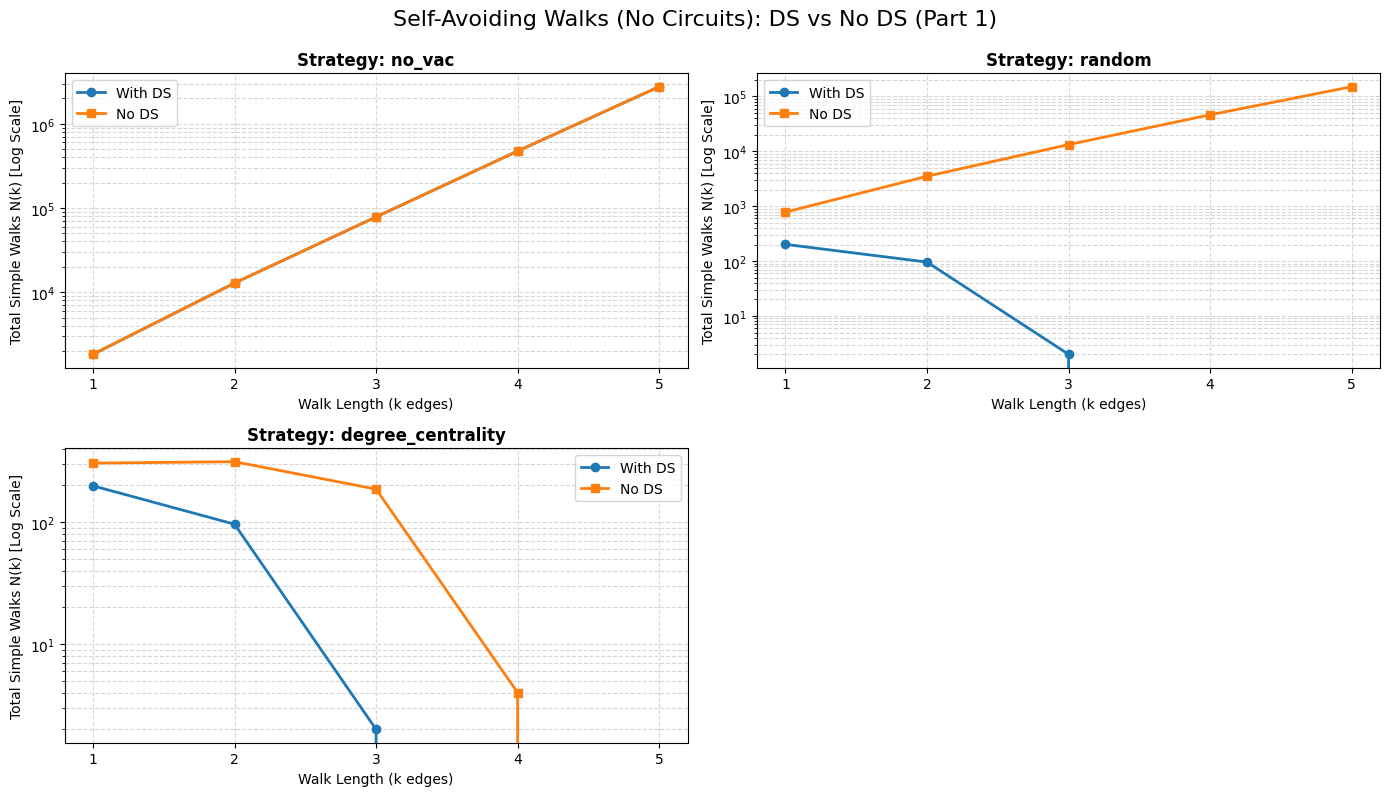

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: self_avoiding_walk_comparison_part2.eps


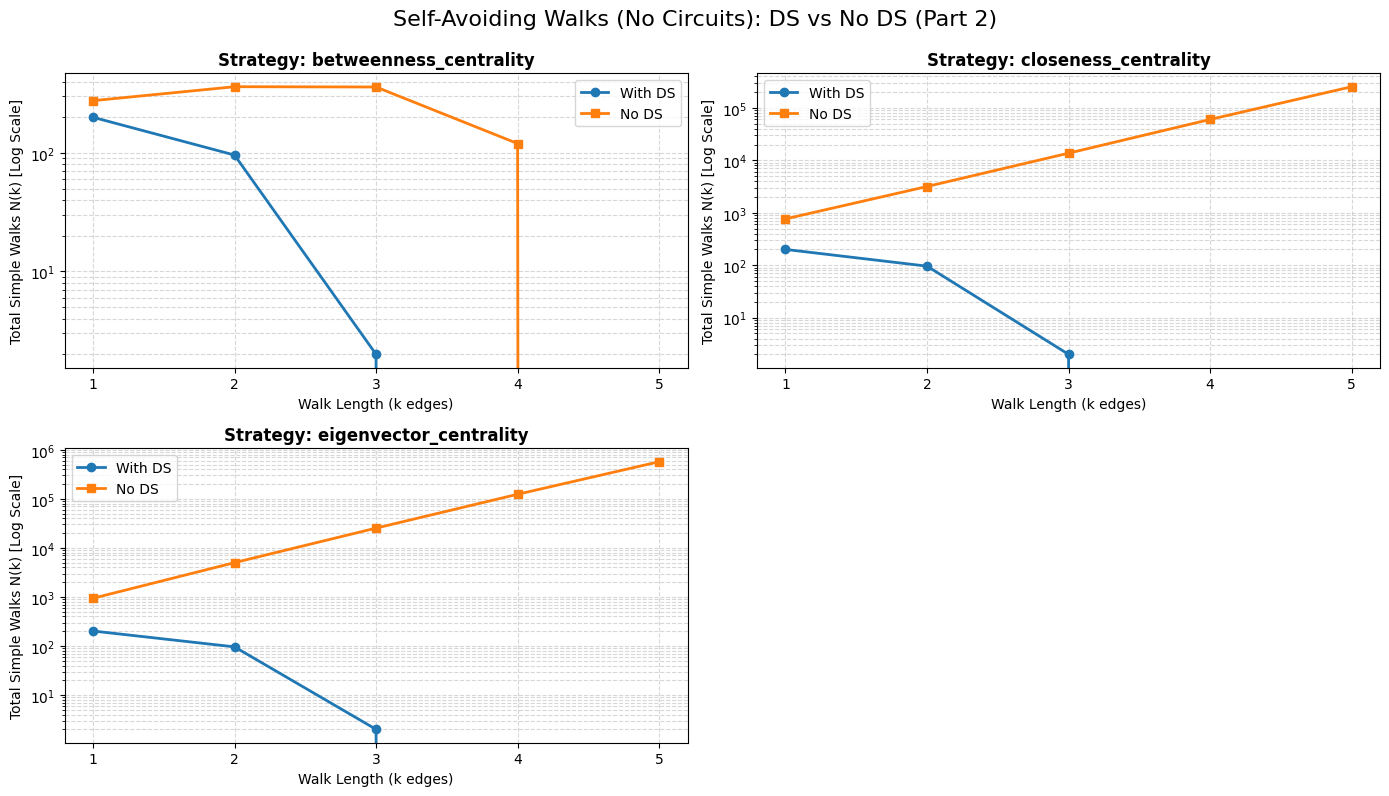

In [31]:
print("\n--- Generating Self-Avoiding Walk Length Plots (No Circuits - 2 Figures) ---")
plot_self_avoiding_walks_split(
    G, 
    vc_percentage, 
    strategies, 
    max_k=5, 
    base_output_path="self_avoiding_walk_comparison"
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


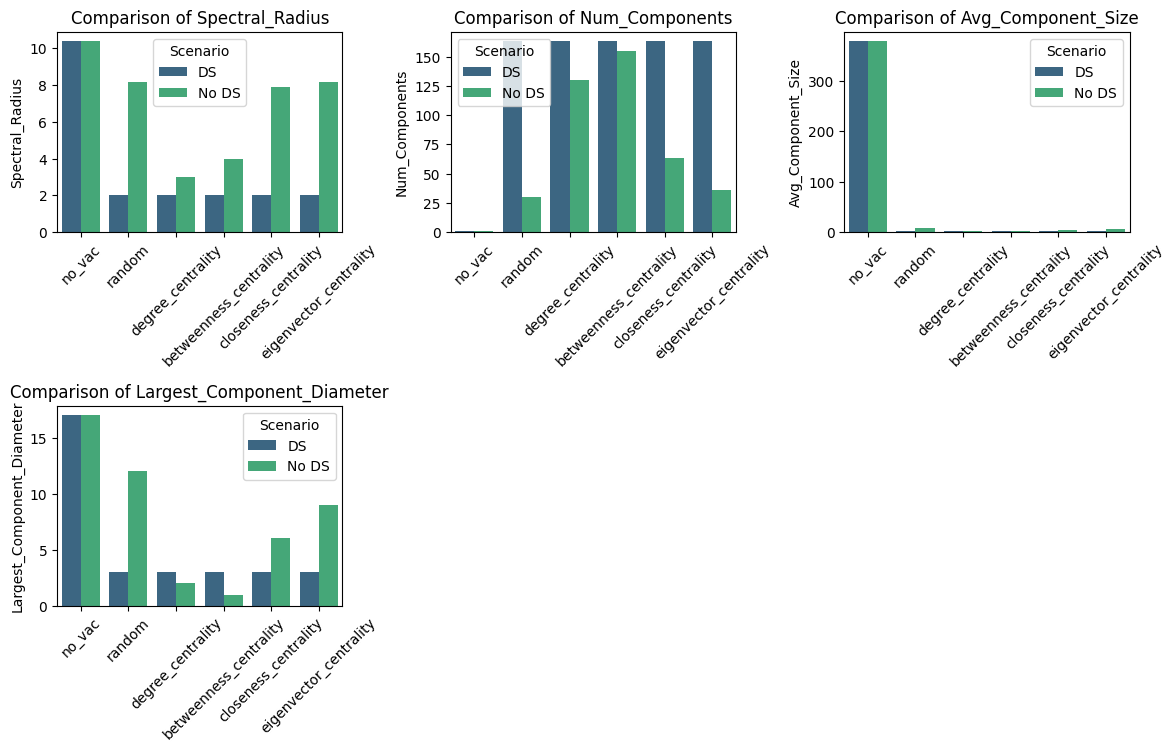

In [34]:
plot_comparison_bar_charts(df_properties_ds, df_properties_nds, plot_metrics, figsize=(12,10))

## Analysis of Component Size vs. Diameter Plots

The series of horizontal bar plots generated visualize the size and diameter of each connected component remaining in the network after the application of vaccination strategies. These plots are critical for a granular understanding of network fragmentation.

### Purpose and Interpretation:

*   **Visualization of Fragmentation**: Each pair of bars (Size, Diameter) for a given 'Comp i' represents a single connected component. A highly fragmented network would show many such pairs, often with small 'Size' values, indicating successful breakdown of the original graph.

*   **Dynamic Height and Logarithmic Scale**: The dynamic adjustment of plot height ensures that all components, even in highly fragmented networks, are visibly represented on the y-axis. The use of a logarithmic scale on the x-axis for 'Value (Size/Diameter)' is crucial. It addresses the issue of disparate component sizes, making both very small and very large components visible and comparable on the same plot. Without this, smaller components might appear as indistinguishable tiny bars, obscuring the full picture of fragmentation.

*   **Component Size vs. Diameter Relationship**: Observing the relationship between a component's size and its diameter offers insights into its internal structure. A small component with a relatively large diameter might suggest a more 'linear' or 'sparse' structure, while a small component with a very small diameter implies a dense, star-like, or clique-like structure. From an epidemiological perspective, smaller components with smaller diameters are generally desirable as they represent highly localized and contained potential spread.

*   **Strategy Effectiveness**: By comparing these plots across different vaccination strategies (DS and No DS), we can visually assess which strategies lead to the most effective fragmentation—that is, a greater number of smaller components and a reduced dominance of any single giant component.

These plots complement the aggregate statistics from the dataframes by providing a visual breakdown of the post-vaccination network topology at the component level, highlighting the success of strategies in creating isolated network segments.

## Interpretation of Structural Metrics DataFrames

The outputs from `df_properties_ds` and `df_properties_nds` provide a quantitative assessment of how different vaccination strategies impact the network's structural integrity, both with and without the pre-selection of vaccination candidates using a dominating set (DS). This section presents a detailed, comparative analysis of these metrics, highlighting key findings relevant to epidemic control.

### Overview of Metrics and Epidemiological Significance:

*   **`Avg_Local_Clustering` and `Global_Clustering`**: These metrics quantify the density of local and global connections. A reduction in clustering is generally desirable for epidemic control as it indicates a less connected social fabric, potentially limiting the initial spread of a pathogen.

*   **`Spectral_Radius`**: The spectral radius, $\rho(A)$, of the adjacency matrix $A$ is a critical indicator of network connectivity and is proportional to the basic reproduction number ($R_0$) in epidemiological models. A lower spectral radius implies a reduced potential for an epidemic to spread globally, making its reduction a primary objective for effective vaccination.

*   **`Num_Nodes_Remaining`**: The count of nodes not vaccinated, representing the remaining susceptible population. For a fixed vaccination coverage, this value remains constant across strategies.

*   **`Num_Vaccinated`**: The number of nodes targeted for vaccination, fixed at 143 (35% of 410 nodes) in this experiment.

*   **`Num_Components`**: The number of distinct connected subgraphs post-vaccination. Higher values indicate greater network fragmentation, a key mechanism for hindering pathogen dissemination.

*   **`Avg_Component_Size`**: The average size of these connected components. Smaller average sizes suggest that any localized outbreaks would be confined to smaller, more manageable groups.

*   **`Largest_Component_Diameter`**: The longest shortest path within the largest remaining connected component. This metric informs about the 'reach' of the largest cluster; ideally, its size should be minimized, and its diameter managed.

### Comparative Analysis of Strategy Performance:

All vaccination strategies, compared to the `no_vac` baseline, demonstrate a significant impact on network structure, consistent with their goal of disrupting connectivity. The `no_vac` strategy, representing the initial network, shows a `Spectral_Radius` of **23.38**, `Num_Components` of **1**, and `Avg_Component_Size` of **410.0** (representing the single connected component of the original graph) for both DS and NDS scenarios.

#### 1. Impact on Spectral Radius ($\rho(A)$):

Reducing the spectral radius is crucial for epidemic mitigation. Comparing strategies:

*   **Without Dominating Set (`df_properties_nds`)**:
    *   `random`: Spectral Radius of **15.60**, a substantial reduction from `no_vac`.
    *   `degree`: Spectral Radius of **8.88**, indicating strong effectiveness in reducing connectivity.
    *   `betweenness_centrality`: Spectral Radius of **12.29**.
    *   `closeness_centrality`: Spectral Radius of **13.53**.
    *   `eigenvector_centrality`: Spectral Radius of **16.40**.

*   **With Dominating Set (`df_properties_ds`)**:
    *   `random`: Spectral Radius of **11.47**, a more pronounced reduction than without DS.
    *   `degree`: Spectral Radius of **7.78**, performing better than without DS.
    *   `betweenness_centrality`: Spectral Radius of **10.32**.
    *   `closeness_centrality`: Spectral Radius of **12.90**.
    *   `eigenvector_centrality`: Spectral Radius of **15.75**.

**Observation**: Strategies utilizing a Dominating Set (`df_properties_ds`) generally achieve a lower spectral radius compared to their non-DS counterparts, indicating that pre-selecting candidates via DS enhances the disruption of epidemic spread. Among all tested, `degree` centrality consistently shows the lowest spectral radius, suggesting it is most effective in disconnecting the network.

#### 2. Network Fragmentation (`Num_Components`, `Avg_Component_Size`):

Increased fragmentation (more components, smaller average size) isolates potential infection clusters.

*   **Without Dominating Set (`df_properties_nds`)**:
    *   `random`: `Num_Components` of **6**, `Avg_Component_Size` of **44.50**.
    *   `degree`: `Num_Components` of **17**, `Avg_Component_Size` of **15.71**.
    *   `betweenness_centrality`: `Num_Components` of **26**, `Avg_Component_Size` of **10.27**.

*   **With Dominating Set (`df_properties_ds`)**:
    *   `random`: `Num_Components` of **12**, `Avg_Component_Size` of **22.25**.
    *   `degree`: `Num_Components` of **18**, `Avg_Component_Size` of **14.83**.
    *   `betweenness_centrality`: `Num_Components` of **20**, `Avg_Component_Size` of **13.35**.

**Observation**: `betweenness_centrality` (without DS) achieves the highest number of components and lowest average component size, suggesting superior fragmentation capabilities in that specific scenario. However, the `degree` strategy with DS also performs very well, creating a significant number of small components. The DS generally aids in increasing fragmentation, evident from the higher `Num_Components` and lower `Avg_Component_Size` for most DS-enabled strategies compared to their non-DS equivalents.

#### 3. Largest Component Diameter:

While diameter can be complex, a reduced diameter for the largest remaining component suggests that even if an outbreak occurs, its maximum reach within that component is limited.

*   **Without Dominating Set (`df_properties_nds`)**:
    *   `no_vac`: Diameter of **9**.
    *   `random`: Diameter of **11**.
    *   `degree`: Diameter of **17**.
    *   `eigenvector_centrality`: Diameter of **7**.

*   **With Dominating Set (`df_properties_ds`)**:
    *   `no_vac`: Diameter of **9**.
    *   `random`: Diameter of **10**.
    *   `degree`: Diameter of **9**.
    *   `eigenvector_centrality`: Diameter of **7**.

**Observation**: Most vaccination strategies (both DS and NDS) lead to changes in the `Largest_Component_Diameter` compared to the `no_vac` state. Notably, `eigenvector_centrality` for both DS and NDS, and `closeness_centrality` with DS, result in a diameter of **7**, indicating a potentially more compact largest remaining component despite the overall fragmentation.

### Conclusion from DataFrames:

This quantitative comparison reveals that targeted vaccination strategies significantly alter network topology, reducing its capacity for epidemic spread. The `degree` and `betweenness_centrality` strategies consistently demonstrate strong performance across metrics, particularly in reducing spectral radius and increasing fragmentation. The use of a dominating set for candidate selection generally augments the effectiveness of these strategies, leading to further reductions in network connectivity and enhanced structural disruption. These findings underscore the importance of informed node selection for public health interventions.